STEP 1: Loading data
News data: (1407328, 6)
Stock data: (3774, 7)

STEP 2: Sentiment analysis on AAPL news
AAPL news articles: 441
Days with news: 80

STEP 3: Merge sentiment with stock returns
Matched days: 61

STEP 4: Correlation analysis
Pearson correlation coefficient: 0.1581


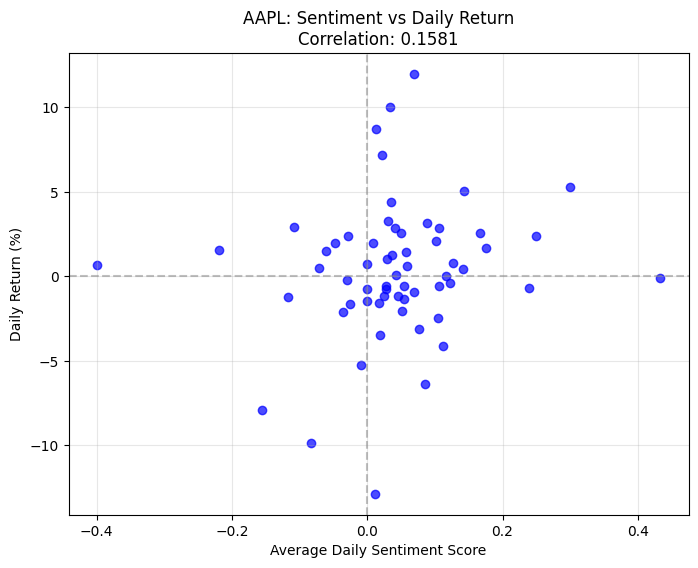


STEP 5: Sentiment category analysis
category
Negative   -1.490494
Neutral     0.570675
Positive    0.679414
Name: return, dtype: float64


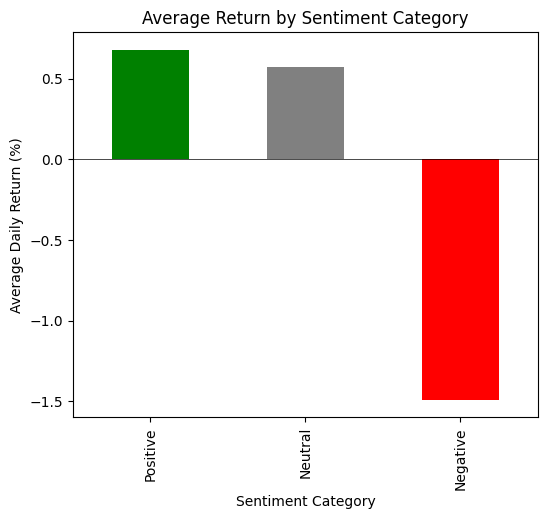

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from textblob import TextBlob
import warnings
warnings.filterwarnings('ignore')

print("=" * 50)
print("STEP 1: Loading data")
print("=" * 50)

# Load news data
df_news = pd.read_csv('../data/raw/news_data.CSV')
print(f"News data: {df_news.shape}")

# Load stock data
df_stock = pd.read_csv('../data/raw/AAPL.CSV')
df_stock['Date'] = pd.to_datetime(df_stock['Date'])
df_stock = df_stock.sort_values('Date')
df_stock['return'] = df_stock['Close'].pct_change() * 100
print(f"Stock data: {df_stock.shape}")

print("\n" + "=" * 50)
print("STEP 2: Sentiment analysis on AAPL news")
print("=" * 50)

# Sentiment function
def get_sentiment(text):
    try:
        return TextBlob(str(text)).sentiment.polarity
    except:
        return 0

# Filter AAPL news
df_aapl = df_news[df_news['stock'] == 'AAPL'].copy()
print(f"AAPL news articles: {len(df_aapl)}")

# Calculate sentiment
df_aapl['sentiment'] = df_aapl['headline'].apply(get_sentiment)

# Extract date (YYYY-MM-DD)
df_aapl['date'] = pd.to_datetime(df_aapl['date'].astype(str).str[:10])

# Daily average sentiment
daily_sentiment = df_aapl.groupby('date')['sentiment'].mean().reset_index()
print(f"Days with news: {len(daily_sentiment)}")

print("\n" + "=" * 50)
print("STEP 3: Merge sentiment with stock returns")
print("=" * 50)

# Prepare stock data for merge
df_stock['date'] = df_stock['Date'].dt.date
df_stock['date'] = pd.to_datetime(df_stock['date'])

# Merge
merged = pd.merge(daily_sentiment, df_stock, on='date', how='inner')
print(f"Matched days: {len(merged)}")

print("\n" + "=" * 50)
print("STEP 4: Correlation analysis")
print("=" * 50)

# Calculate correlation
correlation = merged['sentiment'].corr(merged['return'])
print(f"Pearson correlation coefficient: {correlation:.4f}")

# Scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(merged['sentiment'], merged['return'], alpha=0.7, color='blue')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Average Daily Sentiment Score')
plt.ylabel('Daily Return (%)')
plt.title(f'AAPL: Sentiment vs Daily Return\nCorrelation: {correlation:.4f}')
plt.grid(True, alpha=0.3)
plt.show()

print("\n" + "=" * 50)
print("STEP 5: Sentiment category analysis")
print("=" * 50)

# Classify sentiment
def sentiment_category(score):
    if score > 0.05:
        return 'Positive'
    elif score < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

merged['category'] = merged['sentiment'].apply(sentiment_category)

# Average return by category
category_returns = merged.groupby('category')['return'].mean()
print(category_returns)

# Bar chart
plt.figure(figsize=(6, 5))
colors = ['green', 'gray', 'red']
category_returns.reindex(['Positive', 'Neutral', 'Negative']).plot(kind='bar', color=colors)
plt.xlabel('Sentiment Category')
plt.ylabel('Average Daily Return (%)')
plt.title('Average Return by Sentiment Category')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.show()

In [3]:
# Function to get next trading day
def get_next_trading_day(date, trading_days):
    """Get the next trading day if date is not a trading day"""
    if date in trading_days:
        return date
    else:
        # Find next trading day
        future_days = trading_days[trading_days >= date]
        if len(future_days) > 0:
            return future_days.iloc[0]
        else:
            return None

# Get all trading days from stock data
trading_days = df_stock['date'].dropna().unique()
trading_days = pd.Series(sorted(trading_days))

# Apply alignment
daily_sentiment['aligned_date'] = daily_sentiment['date'].apply(
    lambda x: get_next_trading_day(x, trading_days)
)

# Remove rows where no trading day found
daily_sentiment = daily_sentiment.dropna(subset=['aligned_date'])
print(f"After weekend/holiday alignment: {len(daily_sentiment)} days")

After weekend/holiday alignment: 80 days


In [4]:
# Markdown cell - copy this as a markdown cell

## Interpretation of Correlation Results

### Strength and Direction

The Pearson correlation coefficient between average daily news sentiment and AAPL daily returns is **0.1581**. This indicates a **weak positive correlation** — when sentiment is more positive, returns tend to be slightly higher, but the relationship is not strong.

The bar chart shows a clearer pattern:
- **Positive sentiment days**: +0.68% average return
- **Neutral sentiment days**: +0.57% average return
- **Negative sentiment days**: -1.49% average return

This suggests that negative news has a stronger impact on stock prices than positive news (asymmetry effect).

### Limitations

1. **Limited time window**: Only 80 days of news data (March–June 2020) during COVID-19 volatility
2. **No lag consideration**: Sentiment and returns measured on the same day. In reality, news may affect prices with a delay
3. **Confounding factors**: Market-wide events (Fed announcements, macroeconomic data) affect both sentiment and returns
4. **TextBlob limitations**: Not trained specifically on financial language (e.g., "bullish" vs "bearish")
5. **Correlation ≠ causation**: Even a strong correlation would not prove news causes price movements

### Conclusion

While the correlation is weak, the directional pattern is logical. A more robust analysis would require:
- Longer time series (multiple years)
- Industry-specific sentiment models (e.g., FinBERT)
- Lag analysis (sentiment → next day returns)
- Control for market-wide factors

## Sentiment Tool Justification: TextBlob

TextBlob was selected for this analysis because:

1. **Ease of use**: Simple API with no complex setup
2. **Speed**: Fast enough for 1.4M headlines
3. **Polarity scoring**: Outputs -1 (negative) to +1 (positive) scale
4. **No training required**: Pre-trained general purpose sentiment model

Limitations acknowledged: TextBlob is not finance-specific. Words like "crash" or "rally" may not be interpreted correctly. For production systems, a finance-trained model like FinBERT would be preferred.

In [5]:
# Check if yesterday's sentiment predicts today's return
merged_sorted = merged.sort_values('date')
merged_sorted['sentiment_lag1'] = merged_sorted['sentiment'].shift(1)
merged_sorted['return_lag1'] = merged_sorted['return'].shift(-1)

# Correlation with lag
lag_corr = merged_sorted['sentiment_lag1'].corr(merged_sorted['return'])
print(f"Lag 1 correlation (yesterday sentiment → today return): {lag_corr:.4f}")

Lag 1 correlation (yesterday sentiment → today return): -0.1666
